Accuracy (SVM): 0.8012
Precision (SVM): 0.7974
Recall (SVM): 0.8012
F1-Score (SVM): 0.7734

Confusion Matrix (SVM):
[[87378     6 19693]
 [11052    47  1165]
 [ 2919    26 53055]]


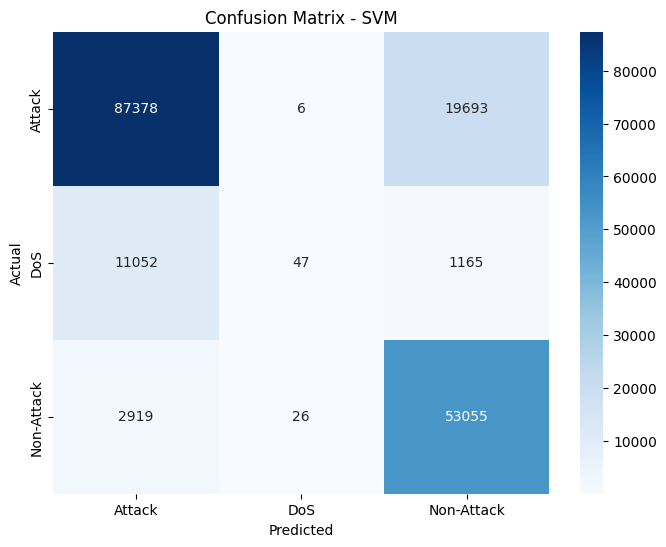

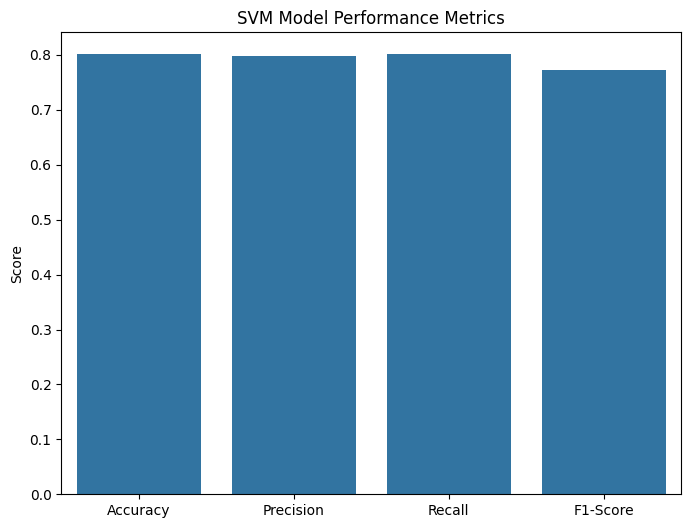

In [ ]:
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

# تجاهل التحذيرات
warnings.filterwarnings("ignore")

# تحميل البيانات
train_df = pd.read_csv('UNSW_NB15_training-set.csv')
test_df = pd.read_csv('UNSW_NB15_testing-set.csv')

# الأعمدة غير الضرورية التي سيتم حذفها
DROP_COLS = ["id", "attack_cat"]
CAT_COLS = ["proto", "service", "state"]

# تطبيق التصنيف بناءً على `attack_cat`
def preprocess(train_df, test_df):
    # Make copies of the original dataframes to work with
    train_df_copy = train_df.copy()
    test_df_copy = test_df.copy()

    # تصنيف الهجمات بناءً على `attack_cat`
    train_df_copy['label'] = train_df_copy['attack_cat'].apply(
        lambda x: 'DoS' if x == 'DoS' else
        'Non-Attack' if x == 'Normal' else
        'Attack'  # تصنيف باقي الهجمات كـ Attack
    )
    test_df_copy['label'] = test_df_copy['attack_cat'].apply(
        lambda x: 'DoS' if x == 'DoS' else
        'Non-Attack' if x == 'Normal' else
        'Attack'  # تصنيف باقي الهجمات كـ Attack
    )

    # إزالة الأعمدة غير الضرورية (id and attack_cat) from the feature set
    train_df_processed = train_df_copy.drop(columns=DROP_COLS, errors="ignore")
    test_df_processed = test_df_copy.drop(columns=DROP_COLS, errors="ignore")

    # تحويل الأعمدة النصية إلى قيم عددية باستخدام LabelEncoder
    for col in CAT_COLS:
        le = LabelEncoder()
        combined = pd.concat([train_df_processed[col], test_df_processed[col]]).astype(str)
        le.fit(combined)
        train_df_processed[col] = le.transform(train_df_processed[col].astype(str))
        test_df_processed[col] = le.transform(test_df_processed[col].astype(str))

    # التعامل مع القيم المفقودة
    train_df_processed = train_df_processed.dropna()
    test_df_processed = test_df_processed.dropna()

    # تقسيم البيانات إلى ميزات (X) وهدف (y)
    X_train = train_df_processed.drop(columns=["label"]).values
    y_train = train_df_processed["label"].values
    X_test = test_df_processed.drop(columns=["label"]).values
    y_test = test_df_processed["label"].values
    return X_train, y_train, X_test, y_test

# تنفيذ المعالجة المبدئية للبيانات
X_train, y_train, X_test, y_test = preprocess(train_df, test_df)

# Encode string labels to numerical labels for Logistic Regression
label_encoder_y = LabelEncoder()
y_train = label_encoder_y.fit_transform(y_train)
y_test = label_encoder_y.transform(y_test)

# ── 3. Normalize features ─────────────────────────────────────
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ── 4. Train & evaluate SVM ─────────────────
model = SVC(kernel="linear", random_state=42)  # يمكنك تغيير نوع kernel إلى 'rbf' أو 'poly' حسب الحاجة
model.fit(X_train, y_train)

# التنبؤ على بيانات الاختبار
y_pred = model.predict(X_test)

# حساب المقاييس: الدقة، الاسترجاع، F1، المصفوفة الارتباك
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0, average="weighted")
rec = recall_score(y_test, y_pred, zero_division=0, average="weighted")
f1 = f1_score(y_test, y_pred, zero_division=0, average="weighted")
cm = confusion_matrix(y_test, y_pred)

# طباعة النتائج
print(f"Accuracy (SVM): {acc:.4f}")
print(f"Precision (SVM): {prec:.4f}")
print(f"Recall (SVM): {rec:.4f}")
print(f"F1-Score (SVM): {f1:.4f}")
print("\nConfusion Matrix (SVM):")
print(cm)

# Get class names for confusion matrix labels
class_names = label_encoder_y.inverse_transform(np.arange(len(label_encoder_y.classes_)))

# رسم المصفوفة الارتباك
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix - SVM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# رسم دقة النموذج
metrics = {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1-Score": f1}
plt.figure(figsize=(8, 6))
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()))
plt.title("SVM Model Performance Metrics")
plt.ylabel("Score")
plt.show()